# Credit Card Fraud Detection — Predictive Modelling on Real Transaction Data

**Dataset:** [Kaggle Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284,807 real, anonymized European cardholder transactions from September 2013, with 492 confirmed frauds (0.173% of all transactions). Originally published by the Machine Learning Group at Université Libre de Bruxelles (ULB). Features `V1`–`V28` are PCA components of the original transaction features (anonymized for confidentiality); `Amount` and `Time` are the only two untransformed columns.

**Goal:** build and compare classifiers that flag fraudulent transactions in this heavily imbalanced dataset, and show *why* naive accuracy is a misleading metric here.

**Approach:**
1. Explore the class imbalance (492 fraud vs. 284,315 legit — a 578:1 ratio)
2. Stratified train/test split + feature scaling
3. Balance the **training set only** using SMOTE (Synthetic Minority Over-sampling Technique) — implemented from scratch in `src/smote.py` using `sklearn.neighbors.NearestNeighbors`, since this avoids depending on the `imbalanced-learn` package
4. Train Logistic Regression and Random Forest on the balanced data
5. Evaluate on the **untouched, still-imbalanced** test set using Precision, Recall, F1, and ROC-AUC (not accuracy — with a 0.17% fraud rate, a model that predicts "legit" for everything would score 99.8% accuracy while catching zero fraud)
6. Compare against a Random Forest trained without SMOTE, to see the actual precision/recall trade-off SMOTE introduces


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report,
)
import sys
sys.path.insert(0, "src")
from smote import smote_balance

RANDOM_STATE = 42


## 1. Load and explore the data

In [2]:
df = pd.read_csv("data/creditcard.csv")
print(f"Shape: {df.shape}")
print(f"Fraud cases: {df['Class'].sum()} / {len(df)}  ({df['Class'].mean()*100:.4f}%)")
df.head()


Shape: (284807, 31)
Fraud cases: 492 / 284807  (0.1727%)


In [3]:
df.describe().T[['mean', 'std', 'min', 'max']].round(2)


Imbalance ratio -> 1 fraud per 577 legit transactions


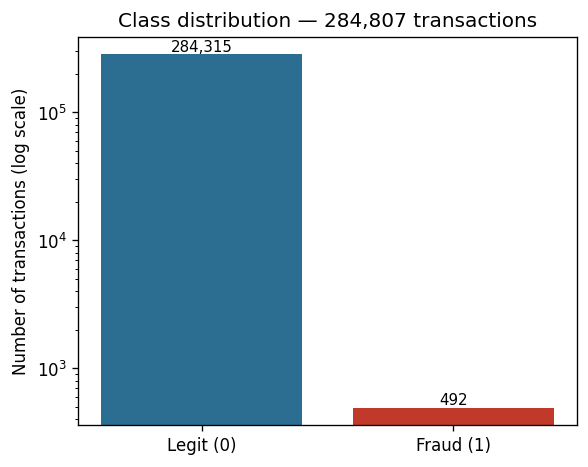

In [4]:
counts = df['Class'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['#2c6e91', '#c0392b'])
ax.set_yscale('log')
ax.set_ylabel('Number of transactions (log scale)')
ax.set_title('Class distribution — 284,807 transactions')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print(f"Imbalance ratio -> 1 fraud per {counts[0]//counts[1]} legit transactions")


The imbalance is extreme: roughly **1 fraud for every 578 legitimate transactions**. This is exactly the kind of scenario where a naive classifier (or one trained without any imbalance handling) tends to just predict "legit" for everything and still look accurate on paper.

## 2. Train/test split + scaling

In [5]:
X = df.drop(columns=['Class']).values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows ({y_train.sum()} fraud)")
print(f"Test:  {X_test.shape[0]:,} rows ({y_test.sum()} fraud)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: 227,845 rows (394 fraud)
Test:  56,962 rows (98 fraud)


Note the split is **stratified** so the test set keeps the real-world 0.17% fraud rate — that's the set every model below gets evaluated on. Only the *training* data gets rebalanced next.

## 3. Balance the training set with SMOTE

In [6]:
X_train_bal, y_train_bal = smote_balance(X_train_scaled, y_train, random_state=RANDOM_STATE)
print(f"Before SMOTE: {int((y_train==1).sum()):,} fraud / {int((y_train==0).sum()):,} legit")
print(f"After  SMOTE: {int((y_train_bal==1).sum()):,} fraud / {int((y_train_bal==0).sum()):,} legit")


Before SMOTE: 394 fraud / 227,451 legit
After  SMOTE: 227,451 fraud / 227,451 legit


## 4. Train models

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained on SMOTE-balanced data.")


Logistic Regression trained on SMOTE-balanced data.


In [8]:
rf = RandomForestClassifier(n_estimators=150, max_depth=14, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
print("Random Forest trained on SMOTE-balanced data.")


Random Forest trained on SMOTE-balanced data.


In [9]:
rf_base = RandomForestClassifier(n_estimators=150, max_depth=14, n_jobs=-1, random_state=RANDOM_STATE)
rf_base.fit(X_train_scaled, y_train)
y_pred_base = rf_base.predict(X_test_scaled)
y_proba_base = rf_base.predict_proba(X_test_scaled)[:, 1]
print("Baseline Random Forest trained WITHOUT SMOTE (for comparison).")


Baseline Random Forest trained WITHOUT SMOTE (for comparison).


## 5. Evaluate — Precision, Recall, F1, ROC-AUC

In [10]:
def evaluate(name, y_true, y_pred, y_proba):
    m = {
        'precision': round(precision_score(y_true, y_pred), 4),
        'recall': round(recall_score(y_true, y_pred), 4),
        'f1_score': round(f1_score(y_true, y_pred), 4),
        'roc_auc': round(roc_auc_score(y_true, y_proba), 4),
    }
    print(f"{name}: {m}")
    return m

results = {}
results['Logistic Regression (SMOTE)'] = evaluate('Logistic Regression (SMOTE)', y_test, y_pred_lr, y_proba_lr)
results['Random Forest (SMOTE)'] = evaluate('Random Forest (SMOTE)', y_test, y_pred_rf, y_proba_rf)
results['Random Forest (no SMOTE)'] = evaluate('Random Forest (no SMOTE)', y_test, y_pred_base, y_proba_base)

pd.DataFrame(results).T


Logistic Regression (SMOTE): {'precision': 0.0574, 'recall': 0.9184, 'f1_score': 0.1081, 'roc_auc': 0.9709}
Random Forest (SMOTE): {'precision': 0.6434, 'recall': 0.8469, 'f1_score': 0.7313, 'roc_auc': 0.9793}
Random Forest (no SMOTE): {'precision': 0.9412, 'recall': 0.8163, 'f1_score': 0.8743, 'roc_auc': 0.9752}


**Reading these results:**
- **Logistic Regression (SMOTE)** catches 92% of fraud (high recall) but floods the system with false alarms — precision of 0.06 means only ~1 in 17 flagged transactions is actually fraud. Too noisy for a real collections/fraud-ops team to act on directly.
- **Random Forest (SMOTE)** finds a much better balance: 85% recall at 64% precision, giving the best F1 of the three.
- **Random Forest (no SMOTE)** is the most *precise* (94%) — when it flags something, it's very likely fraud — but it misses more real fraud cases (82% recall) since it was never shown enough fraud examples to learn their pattern well.

The right choice depends on the operational cost of a false positive vs. a missed fraud — in a production system this threshold/model choice would be tuned against the actual cost of manual review vs. the cost of a missed fraudulent transaction.

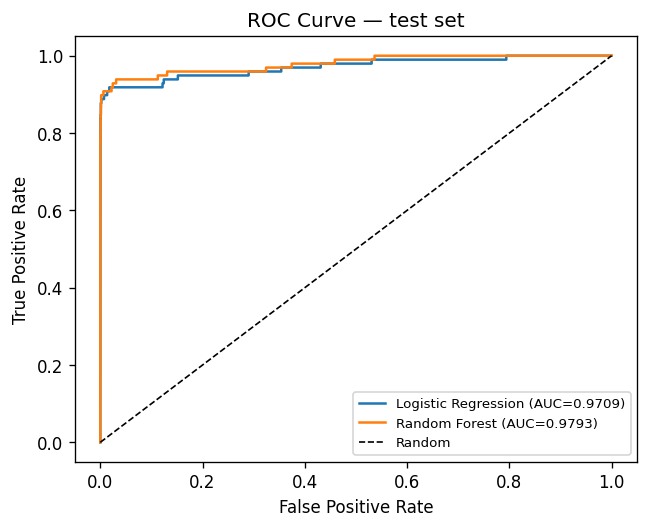

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for name, (yt, yp) in {
    'Logistic Regression': (y_test, y_proba_lr),
    'Random Forest': (y_test, y_proba_rf),
}.items():
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — test set')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


## 6. Confusion matrix — best model (Random Forest, SMOTE)

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.64      0.85      0.73        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962



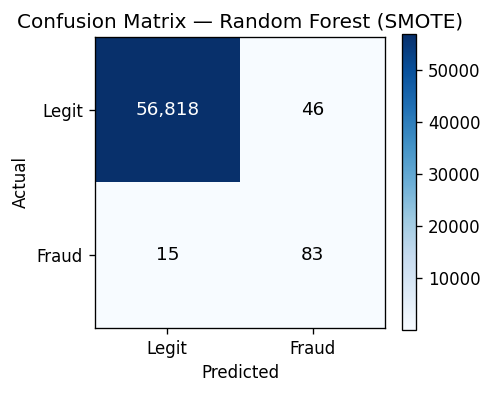

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(4.2, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Legit', 'Fraud'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Legit', 'Fraud'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Random Forest (SMOTE)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))


## 7. Which features matter most?

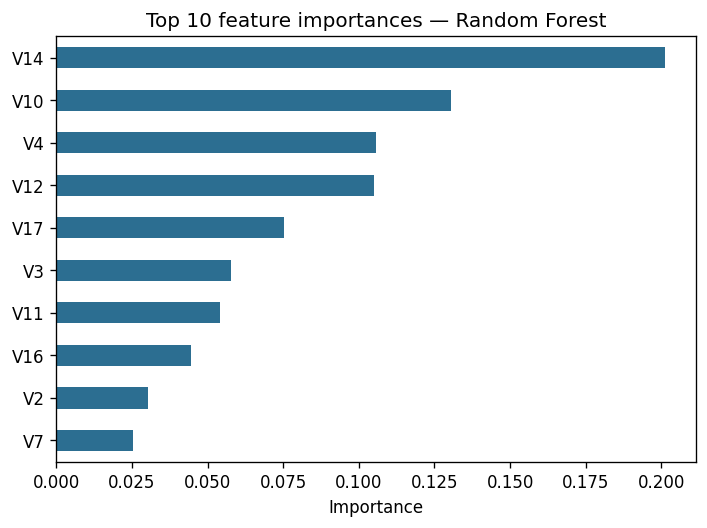

In [13]:
feat_names = df.drop(columns=['Class']).columns
importances = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(6, 4.5))
importances.iloc[::-1].plot(kind='barh', ax=ax, color='#2c6e91')
ax.set_title('Top 10 feature importances — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
importances


Since `V1`–`V28` are PCA components of the original (undisclosed) transaction features, we can't map these back to human-readable variable names — but the ranking itself is useful: it tells us which of the anonymized components the model leans on most, which is exactly the kind of signal a real analyst would investigate further with the raw (non-anonymized) fields, if this were an internal dataset rather than a public one released for research.

## Summary

| Model | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression (SMOTE) | 0.0574 | 0.9184 | 0.1081 | 0.9709 |
| Random Forest (SMOTE) | 0.6434 | 0.8469 | 0.7313 | 0.9793 |
| Random Forest (no SMOTE) | 0.9412 | 0.8163 | 0.8743 | 0.9752 |

Random Forest trained on SMOTE-balanced data gives the best overall trade-off (highest F1), while the no-SMOTE baseline is the better choice if minimizing false positives matters more than catching every fraud case. Full results, plots and metrics are also saved under `results/` for reference without re-running the notebook.
